In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
meta = pd.read_csv('HAM10000_metadata.csv')
meta.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
!pip install -q --upgrade wandb

In [ ]:
import os
import wandb

import numpy as np
import random
from tqdm import *

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets
import torchvision.transforms as transforms

try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

import matplotlib.pyplot as plt
%matplotlib inline

[INFO] Couldn't find torchinfo... installing it.


In [ ]:
def seed_everything(seed):
    random.seed(seed) # фиксируем генератор случайных чисел
    os.environ['PYTHONHASHSEED'] = str(seed) # фиксируем заполнения хешей
    np.random.seed(seed) # фиксируем генератор случайных чисел numpy
    torch.manual_seed(seed) # фиксируем генератор случайных чисел pytorch
    torch.cuda.manual_seed(seed) # фиксируем генератор случайных чисел для GPU
    torch.backends.cudnn.deterministic = True # выбираем только детерминированные алгоритмы (для сверток)
    torch.backends.cudnn.benchmark = False # фиксируем алгоритм вычисления сверток

In [ ]:
from google.colab import userdata
api = userdata.get('w&b_api') # тут нужно в клюс апишку вставить

In [ ]:
class CFG: # общие параметры, для каждого запуска устанавливал свои
  api = api
  project = "GP_5_Skin_DL"
  entity = "" # можно оставить пустым или вписать свой логин/team
  num_epochs = 10
  train_batch_size = 32
  test_batch_size = 512
  num_workers = 2
  lr = 3e-4
  seed = 42
  wandb = True
  image_size = 64

In [ ]:
def class2dict(f):
  return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

# Изучаем данные

In [ ]:
len(meta)

In [ ]:
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


Text(0.5, 1.0, 'Распределение классов dx')

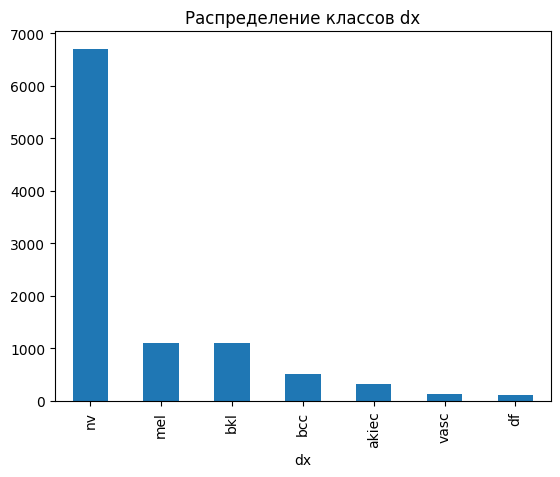

In [ ]:
meta['dx'].value_counts().plot(kind='bar')
plt.title('Распределение классов dx')
# nv - родинка
# mel - рак кожи
# bkl - доброкачественное образование
# bcc - рак кожи
# akiec - ранняя форма рака или предраковое
# df - доброкачественное

https://discuss.pytorch.org/t/understanding-transform-normalize/21730/13 тут нашел такие параметры

In [ ]:
INPUT_DIR = "content/ham10000_images"
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(72),# меняем размер
        transforms.RandomCrop(64),# вырезаем случайную область указанного размера
        transforms.RandomHorizontalFlip(),# зеркальное отражение по горизонтали
        transforms.ToTensor(),
        transforms.Normalize( # https://discuss.pytorch.org/t/understanding-transform-normalize/21730/13 тут нашел такие параметры
            (0.5, 0.5, 0.5),
            (0.5, 0.5, 0.5)
        )]),
    "val": transforms.Compose([# на валидации нельзя делать никаких преобразований (кроме изменения размера),
        transforms.Resize(72),# ведь мы должны проверить модель на реальных картинках
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5, 0.5, 0.5),
            (0.5, 0.5, 0.5)
        )]),
    "test": transforms.Compose([
    transforms.Resize(72),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )])
}


In [ ]:
dataset = {ds: torchvision.datasets.ImageFolder(
    root=os.path.join(INPUT_DIR, ds),
    transform=data_transforms[ds]
) for ds in ['train', 'val', 'test']}

In [ ]:
dataset_size = {ds: len(dataset[ds]) for ds in ['train', 'val', 'test']}
dataset_size

In [ ]:
dataset_classes = dataset['train'].classes

num_classes = len(dataset_classes)

In [ ]:
dataloader = {
    'train': torch.utils.data.DataLoader( dataset=dataset['train'], batch_size=CFG.train_batch_size,
    shuffle=True, num_workers=2
    ),
    'val': torch.utils.data.DataLoader( dataset=dataset['val'], batch_size=CFG.test_batch_size,
    shuffle=False,num_workers=2
    ),
    'test': torch.utils.data.DataLoader(dataset=dataset['test'],batch_size=CFG.test_batch_size,
    shuffle=False, num_workers=2),}

In [ ]:
train_loader_c = dataloader['train']
val_loader_c = dataloader['val']
test_loader_c = dataloader['test']

# CNN

In [ ]:
class ham_Net(torch.nn.Module): # тут без нормализации
    def __init__(self):
        super(ham_Net, self).__init__()

        self.conv1 = torch.nn.Conv2d(3, 16, 3, padding=1)
        self.act1  = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2, 2)

        self.conv2 = torch.nn.Conv2d(16, 32, 3, padding=1)
        self.act2  = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2, 2)

        self.conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.act3  = torch.nn.ReLU()

        self.fc1   = torch.nn.Linear(16 * 16 * 64, 256) # подстраиваем
        self.act4  = torch.nn.Tanh()

        self.fc2   = torch.nn.Linear(256, 64)
        self.act5  = torch.nn.Tanh()

        self.fc3   = torch.nn.Linear(64, 7) # тут классы

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.act3(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))
        x = self.fc1(x)
        x = self.act4(x)
        x = self.fc2(x)
        x = self.act5(x)
        x = self.fc3(x)

        return x

In [ ]:
model_CNN = ham_Net()

In [ ]:
def train(model, device, train_loader, optimizer, criterion, epoch, WANDB):
    model.train()
    true_positive = [0]*7
    false_positive = [0]*7
    false_negative = [0]*7
    train_loss = 0
    correct = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad() # обнуляем градиенты
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        loss = criterion(output, target)
        train_loss += loss.item() # считаем сумму каждого лоса по батчам
        loss.backward() # обратный проход
        optimizer.step() # делаем шаг оптимизатором

        for class_number in range(7):

            true_positive[class_number]+=((pred == class_number)*(target.view_as(pred)==class_number)).sum().item()
            false_positive[class_number]+=((pred == class_number)*(target.view_as(pred) != class_number)).sum().item()
            false_negative[class_number] += ((pred != class_number)*(target.view_as(pred) == class_number)).sum().item()
    precision_sum = 0
    recall_sum = 0
    f1_sum = 0

    for class_number in range(7):
        if true_positive[class_number] + false_positive[class_number] == 0:
            class_precision = 0
        else:
            class_precision = (true_positive[class_number]/(true_positive[class_number] + false_positive[class_number]))

        if true_positive[class_number] + false_negative[class_number] == 0:
            class_recall = 0
        else:
            class_recall = (true_positive[class_number]/(true_positive[class_number] + false_negative[class_number]) )

        if class_precision + class_recall == 0:
            class_f1 = 0
        else:
            class_f1 = (2*class_precision*class_recall/(class_precision+class_recall))

        precision_sum += class_precision
        recall_sum += class_recall
        f1_sum += class_f1

    precision = precision_sum/7
    recall = recall_sum/7
    f1 = f1_sum/7

    train_loss = train_loss/len(train_loader)
    accuracy = correct / len(train_loader.dataset)
    if WANDB:
        wandb.log({
            'train_loss': train_loss,
            'train_accuracy': accuracy,
            'train_precision': precision,
            'train_recall': recall,
            'train_f1': f1
        })
    return f1

In [ ]:
all_targets = [] # тут я собираю для метрик
all_predictions = []

In [ ]:
# функция инференса
def test(model, device, test_loader, criterion, WANDB, phase):
    true_positive=[0]*7
    false_positive=[0]*7
    false_negative=[0]*7
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

            for class_number in range(7):
                true_positive[class_number]+=((pred==class_number)*(target.view_as(pred)==class_number)).sum().item()
                false_positive[class_number]+=((pred==class_number)*(target.view_as(pred)!=class_number)).sum().item()
                false_negative[class_number]+=((pred!=class_number)*(target.view_as(pred)==class_number)).sum().item()

    precision_sum = 0
    recall_sum = 0
    f1_sum = 0

    for class_number in range(7):
        if true_positive[class_number] + false_positive[class_number] == 0:
            class_precision = 0
        else:
            class_precision = (true_positive[class_number]/(true_positive[class_number] + false_positive[class_number]))

        if true_positive[class_number] + false_negative[class_number] == 0:
            class_recall = 0
        else:
            class_recall = (true_positive[class_number]/(true_positive[class_number] + false_negative[class_number]))

        if class_precision + class_recall == 0:
            class_f1 = 0
        else:
            class_f1 = ( 2 * class_precision * class_recall/(class_precision + class_recall))

        precision_sum += class_precision
        recall_sum += class_recall
        f1_sum += class_f1

    precision = precision_sum/7
    recall = recall_sum/7
    f1 = f1_sum/7
    test_loss = test_loss/len(test_loader)
    if WANDB:
        wandb.log({
            phase+'_loss': test_loss,
            phase+'_accuracy': correct/len(test_loader.dataset),
            phase+'_precision': precision,
            phase+'_recall': recall,
            phase+'_f1': f1})
    return f1

In [ ]:
def main_HAM(model):

    if CFG.wandb:
        os.environ["WANDB_API_KEY"] = CFG.api
        wandb.init(project=CFG.project, entity=CFG.entity, reinit=True, config={ "model_name": "simple_cnn", "architecture": "ham_Net",
"image_size": CFG.image_size, "kolichestvo_classes": 7, "learning_rate": CFG.lr, "epochs": CFG.num_epochs,
"train_batch_size": CFG.train_batch_size, "test_batch_size": CFG.test_batch_size, "seed": CFG.seed, "Dataset": 'https://drive.google.com/drive/folders/1z2KSbQ-7wghgocmHm5o33nln-_Ltp5jI?usp=sharing'})

    use_cuda = torch.cuda.is_available()

    seed_everything(CFG.seed)

    device = torch.device("cuda" if use_cuda else "cpu")

    model = model.to(device)

    if CFG.wandb:
        wandb.watch(model, log='all')

    optimizer = optim.Adam(model.parameters(),
                          lr=CFG.lr)
    criterion = nn.CrossEntropyLoss()
    best_f1 = 0
    for epoch in range(1, CFG.num_epochs + 1):
        train(model, device, train_loader_c, optimizer, criterion, epoch, CFG.wandb)
        val_f1 = test( model, device, val_loader_c, criterion, CFG.wandb, 'val' )

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_CNN.pt")
    model.load_state_dict("best_model_CNN.pt")
    test(model, device, test_loader_c, criterion, CFG.wandb, 'test')
    return model

In [ ]:
model_CNN = main_HAM(model_CNN)

Вот пример сохранения модели https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html   
а вот пример загрузки артефакта https://docs.wandb.ai/models/artifacts/artifacts-walkthrough


In [ ]:
torch.save( model_CNN.state_dict(),  "model_CNN.pt")
artifact = wandb.Artifact(name="model_CNN", type="model")
artifact.add_file("model_CNN.pt")
wandb.log_artifact(artifact)

In [ ]:
artifact = wandb.Artifact(name="metadata", type="meta_data")
artifact.add_file('HAM10000_metadata.csv')
wandb.log_artifact(artifact)

# AlexNet с заморозкой слоев

In [ ]:
from torchvision.models import alexnet
from torchvision.models import AlexNet_Weights

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

BATCH_SIZE = 8


In [ ]:
# выполним трансформации

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256), # меняем размер
        transforms.RandomCrop(244), # вырезаем случайную область указанного размера
        transforms.RandomHorizontalFlip(), # зеркальное отражение по горизонтали
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD) # нормализация
        ]),

    'val': transforms.Compose([
        # на валидации нельзя делать случайные преобразования,
        # ведь мы должны проверить модель на реальных картинках
        transforms.Resize(256),
        transforms.CenterCrop(244),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),

    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(244),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
}

In [ ]:
dataset = {ds: torchvision.datasets.ImageFolder(
    root=os.path.join(INPUT_DIR, ds),
    transform=data_transforms[ds]
) for ds in ['train', 'val','test']}

dataset_size = {ds: len(dataset[ds]) for ds in ['train', 'val','test']}
dataset_classes = dataset['train'].classes
print('classes:', dataset_classes, '\nsize', dataset_size)

# загружаем данные
dataloader = {
    'train': torch.utils.data.DataLoader(dataset=dataset['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': torch.utils.data.DataLoader(dataset=dataset['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test': torch.utils.data.DataLoader(dataset=dataset['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2),}

In [ ]:
# функция разбиения по батчам
def get_batches(dataloader, num_of_batches=3):
    assert(num_of_batches > 0)
    images, classes = next(iter(dataloader))
    for _ in range(num_of_batches - 1):
        image_batch, cls_batch = next(iter(dataloader))
        images = torch.cat([images, image_batch], dim=0)
        classes = torch.cat([classes, cls_batch], dim=0)
    return images, classes

In [ ]:
train_loader = dataloader['train']
val_loader = dataloader['val']
test_loader = dataloader['test']

In [ ]:
# функция обучения моделей
def train_model(
    model: torch.nn.Module,
    criterion: torch.nn.Module,
    optimizer: torch.nn.Module,
    sheduler: torch.nn.Module,
    epochs: int = 8
) -> tuple[torch.nn.Module, dict]:

    r"""Обучение модели. Возвращает лучшую модель, словарь потерь при обучении и валидации, словарь точностей при обучении и валидации.
    Args:
        model (torch.nn.Module): модель
        criterion (torch.nn.Module): функция потерь
        optimizer (torch.nn.Module): алгоритм оптимизации
        sheduler (torch.nn.Module): расписание изменения скорости обучения
        epochs (int): количество эпох
    """

    losses = {'train': [], 'val': []}
    accuracies = {'train': [], 'val': []}
    best_model_path = 'best_model.pt'
    best_f1 = 0
    progress = tqdm(range(epochs), desc='Epoch:')

    for epoch in progress:
        for phase in ['train', 'val']:
            loss_accum = 0.
            corr_accum = 0
            model.train(mode=(phase == 'train'))
            if phase == 'val':

                true_positive = [0] * 7
                false_positive = [0] * 7
                false_negative = [0] * 7

            for inputs, labels in tqdm(dataloader[phase], desc=f'Phase {phase}:'):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                if phase == 'train':
                    optimizer.zero_grad()
                    outp = model(inputs)
                    loss = criterion(outp, labels)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        outp = model(inputs)
                        loss = criterion(outp, labels)

                preds = torch.argmax(outp, -1)
                loss_accum += loss.item()
                corr_accum += (preds == labels.data).sum()


                if phase == 'val':
                    for class_number in range(7):
                        true_positive[class_number]+=((preds == class_number)*(labels == class_number)).sum().item()
                        false_positive[class_number]+=((preds == class_number)*(labels != class_number)).sum().item()
                        false_negative[class_number]+=((preds != class_number)*(labels == class_number)).sum().item()

            if phase == 'train':
                sheduler.step()

            epoch_loss = loss_accum / len(dataloader[phase])
            epoch_accuracy = corr_accum / dataset_size[phase]
            losses[phase].append(epoch_loss)
            accuracies[phase].append(epoch_accuracy)

            if CFG.wandb:
                wandb.log({
                    "epoch": epoch + 1,
                    phase + "_loss": epoch_loss,
                    phase + "_accuracy": epoch_accuracy.item()
                })

            if phase == 'val':

                precision_sum = 0
                recall_sum = 0
                f1_sum = 0

                for class_number in range(7):
                    if true_positive[class_number] + false_positive[class_number] == 0:
                        class_precision = 0
                    else:
                        class_precision = (true_positive[class_number]/(true_positive[class_number] + false_positive[class_number]))
                    if true_positive[class_number]+false_negative[class_number] == 0:
                        class_recall=0
                    else:
                        class_recall = ( true_positive[class_number]/(true_positive[class_number] + false_negative[class_number]))
                    if class_precision+class_recall==0:
                        class_f1 = 0
                    else:
                        class_f1 = (2*class_precision*class_recall/(class_precision+class_recall))

                    precision_sum += class_precision
                    recall_sum += class_recall
                    f1_sum += class_f1

                precision = precision_sum/7
                recall = recall_sum/7
                f1 = f1_sum/7

                if CFG.wandb:
                    wandb.log({
                        "epoch": epoch + 1,
                        "val_precision": precision,
                        "val_recall": recall,
                        "val_f1": f1})
            if phase == 'val' and f1 > best_f1:
                best_f1 = f1
                torch.save(model.state_dict(), "best_model_CNN.pt")

    model.load_state_dict("best_model_CNN.pt")
    test(model, DEVICE, dataloader['test'], criterion, CFG.wandb, 'test')
    return model, losses, accuracies

In [ ]:
wandb.init(
    project=CFG.project,
    entity=CFG.entity,
    reinit=True,
    config={
    "model_name": "alexnet_Freez_6)",
    "architecture": "AlexNet",
    "input_size": 244,
    "num_classes": 7,
    "learning_rate": 1e-4,
    "epochs": 8,
    "batch_size": BATCH_SIZE,
    "step_size": 7,
    "gamma": 0.1,
    "Dataset": 'https://drive.google.com/drive/folders/1z2KSbQ-7wghgocmHm5o33nln-_Ltp5jI?usp=sharing'
}
)

In [ ]:
AlexNet = alexnet(weights=AlexNet_Weights.DEFAULT)

In [ ]:
# замораживаем 6 слоев
layers_to_freeze = 6
for i, (name, param) in enumerate(AlexNet.features.named_parameters()):
    if i < layers_to_freeze:
        param.requires_grad = False
    print(f'{name:30}{param.requires_grad}')

In [ ]:
num_in_features = 9216 # входная размерность слоя классификатора
num_out_features = 7 # количество классов

# создаем слой классификатор
AlexNet.classifier = torch.nn.Linear(num_in_features, num_out_features)
AlexNet.to(DEVICE)

wandb.watch(AlexNet, log='all')

# функция потерь кросс-энтропия
loss = torch.nn.CrossEntropyLoss()
retrain_layers = list(AlexNet.features.parameters())[layers_to_freeze:] + list(AlexNet.classifier.parameters())

# обучаем только не замороженные слои
optimizer = torch.optim.Adam(retrain_layers, lr=1e-4)
sheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
model, losses, accuracies = train_model(AlexNet, loss, optimizer, sheduler)

In [ ]:
torch.save(model.state_dict(), "model_alexnet.pt")
artifact = wandb.Artifact( "model_alexnet", type="model")
artifact.add_file("model_alexnet.pt")
wandb.log_artifact(artifact)


artifact = wandb.Artifact(name="metadata", type="meta_data")
artifact.add_file('HAM10000_metadata.csv')
wandb.log_artifact(artifact)

# cnn + batchnorm + dropout

In [ ]:
class Ham_net_batch_drop(torch.nn.Module): # GELU
    def __init__(self):
        super(Ham_net_batch_drop, self).__init__()

        self.batch_norm0 = torch.nn.BatchNorm2d(3) # в качестве параметра указываем только размерность выхода предыдущего слоя

        self.conv1 = torch.nn.Conv2d(3, 16, 3, padding=1)
        self.batch_norm1 = torch.nn.BatchNorm2d(16)
        self.act1  = torch.nn.GELU()
        self.pool1 = torch.nn.MaxPool2d(2, 2)

        self.conv2 = torch.nn.Conv2d(16, 32, 3, padding=1)
        self.batch_norm2 = torch.nn.BatchNorm2d(32)
        self.act2  = torch.nn.GELU()
        self.pool2 = torch.nn.MaxPool2d(2, 2)

        self.conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.batch_norm3 = torch.nn.BatchNorm2d(64)
        self.act3  = torch.nn.GELU()


        self.fc1   = torch.nn.Linear(16*16*64,256)
        self.batch_norm4 = torch.nn.BatchNorm1d(256)
        self.act4  = torch.nn.GELU()

        self.dropout1 = nn.Dropout(0.3)

        self.fc2   = torch.nn.Linear(256, 64)
        self.act5  = torch.nn.GELU()

        self.dropout2 = nn.Dropout(0.25)

        self.fc3   = torch.nn.Linear(64, 7) # клаасы

    def forward(self, x):
        x = self.batch_norm0(x)

        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.batch_norm3(x)
        x = self.act3(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))
        x = self.fc1(x)
        x = self.batch_norm4(x)
        x = self.act4(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.act5(x)
        x = self.dropout2(x)
        x = self.fc3(x)

        return x

In [ ]:
model_CNN_BatchNorm_Dropout = Ham_net_batch_drop()

In [ ]:
def main_HAM_BatchNorm_Dropout(model):

    if CFG.wandb:
        os.environ["WANDB_API_KEY"] = CFG.api
        wandb.init(
            project=CFG.project, entity=CFG.entity, reinit=True,
            config={
                "model_name": "cnn_batchnorm_dropout",
                "architecture": "ham_Net_BatchNorm_Dropout",
                "image_size": CFG.image_size,
                "kolichestvo_classes": num_classes,
                "learning_rate": CFG.lr,
                "epochs": CFG.num_epochs,
                "train_batch_size": CFG.train_batch_size,
                "test_batch_size": CFG.test_batch_size,
                "batch_norm": True,
                "dropout_1": 0.3,
                "dropout_2": 0.25,
                "seed": CFG.seed,
                "Dataset": 'https://drive.google.com/drive/folders/1z2KSbQ-7wghgocmHm5o33nln-_Ltp5jI?usp=sharing'})

    use_cuda = torch.cuda.is_available()

    seed_everything(CFG.seed)

    device = torch.device("cuda" if use_cuda else "cpu")

    model = model.to(device)

    if CFG.wandb:
        wandb.watch(model, log='all')

    optimizer = optim.Adam(model.parameters(),lr=CFG.lr)

    criterion = nn.CrossEntropyLoss()
    best_f1 = 0
    for epoch in range(1, CFG.num_epochs + 1):
        print('\nEpoch:', epoch)
        train( model, device, train_loader_c, optimizer, criterion, epoch, CFG.wandb)
        val_f1= test( model, device, val_loader_c, criterion, CFG.wandb, 'val')

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_CNN_BatchNorm_Dropout.pt")
    model.load_state_dict("best_model_CNN_BatchNorm_Dropout.pt")
    test(model, device, test_loader_c, criterion, CFG.wandb, 'test')
    return model

In [ ]:
model_CNN_Batch_drop= main_HAM_BatchNorm_Dropout(model_CNN_BatchNorm_Dropout)

In [ ]:
torch.save(model_CNN_Batch_drop.state_dict(), "model_CNN_Batch_drop.pt")
artifact = wandb.Artifact("model_CNN_Batch_drop",type="model")
artifact.add_file("model_CNN_Batch_drop.pt")

wandb.log_artifact(artifact)
artifact = wandb.Artifact(name="metadata", type="meta_data")
artifact.add_file('HAM10000_metadata.csv')
wandb.log_artifact(artifact)

# EfficientNet-B0

In [ ]:
from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights



In [ ]:
wandb.init(
    project=CFG.project,
    entity=CFG.entity,
    reinit=True,
    config={
        "model_name": "efficientnet_freez",
        "architecture": "EfficientNet-B0",
        "input_size": 244,
        "num_classes": 7,
        "frozen": True,
        "learning_rate": 1e-4,
        "epochs": 8,
        "batch_size": 8,
        "step_size": 7,
        "gamma": 0.1,
        "Dataset": 'https://drive.google.com/drive/folders/1z2KSbQ-7wghgocmHm5o33nln-_Ltp5jI?usp=sharing'
    }
)


вот тут лежит инфа про параметры https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b0.html

In [ ]:
EfficientNet = efficientnet_b0(weights='DEFAULT')

In [ ]:
for param in EfficientNet.features.parameters():
    param.requires_grad = False

In [ ]:
num_in_features = 1280
num_out_features = 7

# заменяем стандартный классификатор ImageNet на классификатор для 7 классов
EfficientNet.classifier = torch.nn.Linear(num_in_features, num_out_features)
EfficientNet.to(DEVICE)

wandb.watch(EfficientNet, log='all')
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(EfficientNet.classifier.parameters(), lr=1e-4)

# умножаем learning_rate на 0.1 каждые 7 эпох
sheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model_efficientnet, losses_efficientnet, accuracies_efficientnet = train_model(EfficientNet, loss, optimizer, sheduler)

In [ ]:
torch.save(model_efficientnet.state_dict(),"model_efficientnet_b0.pt")

artifact = wandb.Artifact("model_efficientnet_b0", type="model")
artifact.add_file("model_efficientnet_b0.pt")

wandb.log_artifact(artifact)

artifact = wandb.Artifact(name="metadata", type="meta_data")
artifact.add_file('HAM10000_metadata.csv')
wandb.log_artifact(artifact)